<a href="https://colab.research.google.com/github/BilalKhaliqWillis/BILAL-Assignment2/blob/main/BILAL_Final_Project_Sequences%2C_Time_Series_and_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Final Project – Time Series Forecasting
This notebook contains solutions for the final project covering classical time series models and deep learning approaches.

Tasks included:
1. Autocorrelation explanation
2. AutoReg forecasting
3. ARIMA forecasting visualization
4. Classical vs Deep Learning models
5. Vanishing Gradient & LSTM
6. Designing a stock prediction model
7. Handling irregular time series with LSTM
8. GRU model implementation
9. Feature scaling
10. MAPE evaluation and plotting
11. Monitoring models in production


## Import Libraries

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error

from statsmodels.tsa.ar_model import AutoReg
from statsmodels.tsa.arima.model import ARIMA

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import GRU, Dense


## Upload Dataset (Electricity Consumption)

In [ ]:
from google.colab import files
uploaded = files.upload()


Saving electricity_consumption_3yrs.csv to electricity_consumption_3yrs.csv


## Load Dataset

In [ ]:
import pandas as pd
df = pd.read_csv('electricity_consumption_3yrs.csv')
df.head()

,date,load_mwh
0,2020-01-01,304.967142
1,2020-01-02,299.527436
2,2020-01-03,308.296788
3,2020-01-04,317.959517
4,2020-01-05,301.296237


## Data Preprocessing

In [ ]:
df['date'] = pd.to_datetime(df['date'])
df.set_index('date', inplace=True)

df = df.fillna(method='ffill')

df.head()


/tmp/ipykernel_967/3494780695.py:4: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df = df.fillna(method='ffill')


,load_mwh
date,
2020-01-01,304.967142
2020-01-02,299.527436
2020-01-03,308.296788
2020-01-04,317.959517
2020-01-05,301.296237


## Train Test Split

In [ ]:
train_size = int(len(df)*0.8)

train = df[:train_size]
test = df[train_size:]

print("Train size:", len(train))
print("Test size:", len(test))


Train size: 876
Test size: 220


## Scaling Data

In [ ]:
scaler = MinMaxScaler()

train_scaled = scaler.fit_transform(train)
test_scaled = scaler.transform(test)


## AutoReg Model

In [ ]:
model = AutoReg(train_scaled, lags=7)

model_fit = model.fit()

print(model_fit.summary())


                            AutoReg Model Results                             
Dep. Variable:                      y   No. Observations:                  876
Model:                     AutoReg(7)   Log Likelihood                1227.743
Method:               Conditional MLE   S.D. of innovations              0.059
Date:                Sun, 15 Mar 2026   AIC                          -2437.487
Time:                        21:18:38   BIC                          -2394.581
Sample:                             7   HQIC                         -2421.069
                                  876                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0058      0.005      1.052      0.293      -0.005       0.017
y.L1           0.1780      0.034      5.275      0.000       0.112       0.244
y.L2           0.1755      0.034      5.160      0.0

## Forecast using AutoReg

In [ ]:
predictions = model_fit.predict(
    start=len(train_scaled),
    end=len(train_scaled)+len(test_scaled)-1
)

predictions = scaler.inverse_transform(predictions.reshape(-1,1))
actual = test.values


## Forecast Visualization

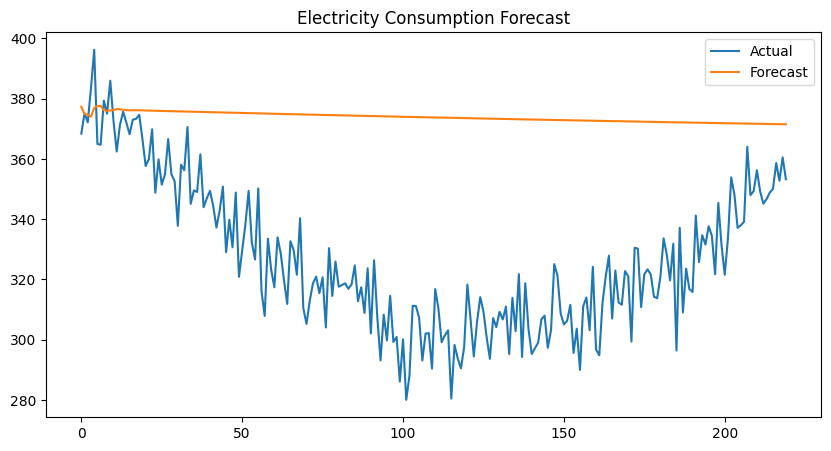

In [ ]:
plt.figure(figsize=(10,5))

plt.plot(actual, label='Actual')
plt.plot(predictions, label='Forecast')

plt.title("Electricity Consumption Forecast")
plt.legend()

plt.show()


## ARIMA Forecast Example

In [ ]:
data = df['load_mwh']

model = ARIMA(data, order=(2,0,2))
model_fit = model.fit()

forecast = model_fit.get_forecast(steps=10)
forecast_values = forecast.predicted_mean


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


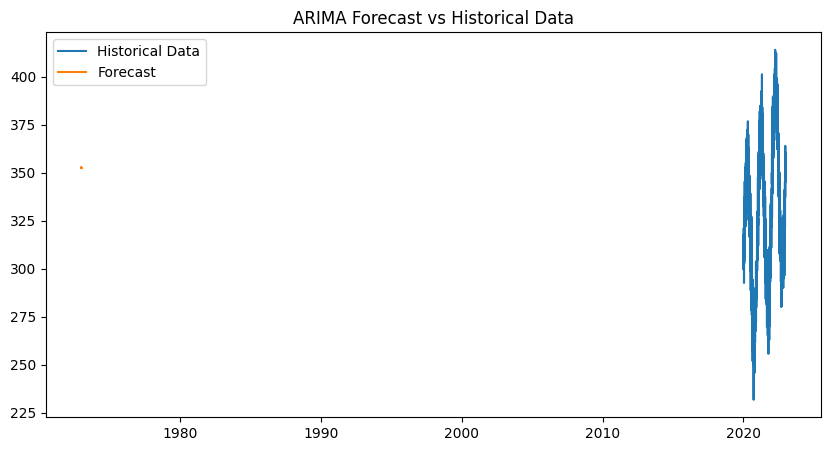

In [ ]:
plt.figure(figsize=(10,5))

plt.plot(data, label='Historical Data')
plt.plot(range(len(data), len(data)+10), forecast_values, label='Forecast')

plt.title("ARIMA Forecast vs Historical Data")
plt.legend()

plt.show()


## GRU Model for Time Series

In [ ]:
model = Sequential()

model.add(GRU(5, input_shape=(6,1)))
model.add(Dense(1))

model.compile(
    optimizer='RMSprop',
    loss='mse'
)

model.summary()


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ gru (GRU)                       │ (None, 5)              │           120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │             6 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 126 (504.00 B)

 Trainable params: 126 (504.00 B)

 Non-trainable params: 0 (0.00 B)

## Scaling Features for RNN

In [ ]:
train_df = pd.DataFrame({
    'load':[120,150,170,200,180],
    'temp':[25,27,30,28,26]
})

scaler = MinMaxScaler()

train_df[['load','temp']] = scaler.fit_transform(
    train_df[['load','temp']]
)

train_df


,load,temp
0,0.000,0.0
1,0.375,0.4
2,0.625,1.0
3,1.000,0.6
4,0.750,0.2


## Model Evaluation (MAPE)

In [ ]:
results_df = pd.DataFrame({
    'actual':[100,120,130,150,170],
    'prediction':[98,125,128,140,175]
})

mape = np.mean(
    np.abs((results_df['actual'] - results_df['prediction']) / results_df['actual'])
) * 100

print("MAPE:", mape)


MAPE: 3.4625942684766216


## Prediction vs Actual Plot

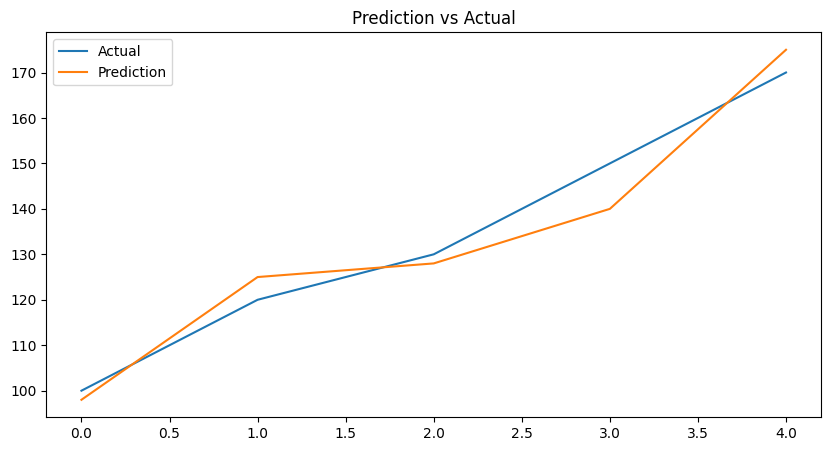

In [ ]:
plt.figure(figsize=(10,5))

plt.plot(results_df['actual'][:200], label='Actual')
plt.plot(results_df['prediction'][:200], label='Prediction')

plt.title("Prediction vs Actual")
plt.legend()

plt.show()


## Monitoring Forecasting Models in Production

In production systems, forecasting models can degrade over time due to **concept drift** or changes in external conditions.

One approach is to continuously monitor performance using metrics such as:
- MAPE
- RMSE

If the error exceeds a predefined threshold (e.g., MAPE > 10%), an automated workflow can trigger:

1. Data collection of new observations
2. Model retraining
3. Validation testing
4. Deployment of the updated model

This ensures the forecasting system remains accurate over time.
